In [1]:
# from dace_query.sun import Sun
import matplotlib.pyplot as plt
from astropy.io import fits
import os
import numpy as np
import jdcal as j 
from astropy.time import Time
from pathlib import Path

import pandas as pd


from scipy import optimize

from RACCON_Gaussian_fit import *

In [2]:
vsini = 2021.5337025818953

def gaussian2(x, amplitude, mean, stddev,C):
    return C + amplitude * np.exp(-(x-mean)**2/(2*stddev**2))

def speed_bisector_nb(rv,ccf,integrated_bis, change=0):
    ''' Fit the bisector of the CCF with a 5th deg polynomial
    '''
    idxmax=ccf.argmax()
    maxccf=ccf[idxmax]
    maxrv=rv[idxmax]

    xnew = rv
    ynew = ccf


    cutleft=0
    cutright=len(ynew)-1
    # if not integrated_bis: #cut the CCF at the minimum of the wings only for reference CCF, if not there are errors.
    for i in range(len(ynew)):
        if xnew[i]>maxrv:
            if ynew[i]>ynew[i-1] and ynew[i]<0.8*maxccf:
                cutright=i
                break

    for i in range(len(ynew)):
        if xnew[-1-i]<maxrv:
            if ynew[-1-i]>ynew[-i] and ynew[i]<0.8*maxccf:
                cutleft=len(ynew)-i
                break

    cutleft_old = cutleft
    cutright_old = cutright


    # cutleft = cutleft + change
    # cutright = cutright - change

    cutleft = 0
    cutright = -1


    xnew=xnew[cutleft:cutright]
    ynew=ynew[cutleft:cutright]
    
    minright=np.min(ynew[xnew>maxrv])
    minleft=np.min(ynew[xnew<maxrv])
    minccf=np.max(np.array([minright,minleft]))
    
    if integrated_bis:
        ybis=np.linspace(minccf+0.1*(maxccf-minccf),0.99*maxccf,50) #from 5% to maximum
    else:
        ybis=np.linspace(minccf+0.1*(maxccf-minccf),0.999*maxccf,50) #from 5% to maximum
    xbis=np.zeros(len(ybis))

    rv1_list = []
    rv2_list = []
    for i in range(len(ybis)):    
        for j in range(len(ynew)-1):
            if ynew[j]<ybis[i] and ynew[j+1]>ybis[i] and xnew[j]<maxrv:
                rv1=xnew[j]+(xnew[j+1]-xnew[j])*(ybis[i]-ynew[j])/(ynew[j+1]-ynew[j])
            if ynew[j]>ybis[i] and ynew[j+1]<ybis[i] and xnew[j+1]>maxrv:
                rv2=xnew[j]+(xnew[j+1]-xnew[j])*(ybis[i]-ynew[j])/(ynew[j+1]-ynew[j])
        xbis[i]=(rv1+rv2)/2.0 #bisector
        rv1_list.append(rv1)
        rv2_list.append(rv2)

    # xbis[-1]=maxrv #at the top should be max RV

    return cutleft,cutright,xbis,ybis, cutleft_old, cutright_old


def compute_ccf_params(rv,ccf,plot_test, change=0):
    '''
    Compute the parameters of the CCF and its bisector span 
    (10-40% bottom minus 60-90% top)
    '''
    rvs=np.zeros(len(ccf)) #initialize
    fwhm=np.zeros(len(ccf))
    contrast=np.zeros(len(ccf))
    BIS=np.zeros(len(ccf))
    #bisector F/F_c
    raw_xbis = []
    raw_ybis = []


    for i in range(len(ccf)): #loop for each ccf
        ccf[i] = ccf[i] - ccf[i].min() + 0.000001
        #Compute bisector and remove wings
        cutleft0,cutright0,xbis,ybis, cutleft_old, cutright_old=speed_bisector_nb(rv,ccf[i]/ccf[i].max(),integrated_bis=True, change=change) #FAST
        # cutleft0,cutright0,xbis,ybis=nbspectra.speed_bisector_nb(rv,ccf[i],integrated_bis=True) #test


        raw_xbis.append(xbis)
        raw_ybis.append(ybis)
        BIS[i]=np.mean(xbis[np.array(ybis>=0.1) & np.array(ybis<=0.4)])-np.mean(xbis[np.array(ybis<=0.9) & np.array(ybis>=0.6)]) #FAST
        if i==0:
            cutleft,cutright=cutleft0,cutright0
        try:
            popt,_=optimize.curve_fit(gaussian2, rv[cutleft:cutright], ccf[i][cutleft:cutright],p0=[np.max(ccf[i][cutleft:cutright]),rv[cutleft:cutright][np.argmax(ccf[i][cutleft:cutright])]+100,1.5*vsini+1000,0.000001]) #fit a gaussian
        except:
            popt=[1.0,100000.0,1,100000.0]
        contrast[i]=popt[0] #amplitude
        rvs[i]=popt[1] #mean
        fwhm[i]=2*np.sqrt(2*np.log(2))*np.abs(popt[2]) #fwhm relation to std

        if plot_test: 
            # plt.plot(rv,1-ccf[i]/ccf[i].max())
            plt.plot(xbis,1-ybis,'b')
            plt.show(block=True)
    

    return rvs, contrast, fwhm, BIS, raw_xbis, raw_ybis, cutleft, cutright, cutleft_old, cutright_old

In [3]:
ccf_simu_mps = np.loadtxt('/home/sophie-stucki/starsim/starsim/SDO_input/flux_output/ccf_test_mps.txt')
rv_simu_mps = np.loadtxt('/home/sophie-stucki/starsim/starsim/SDO_input/flux_output/rv_test_mps.txt')

rv0 = -1014.13101399

change=10


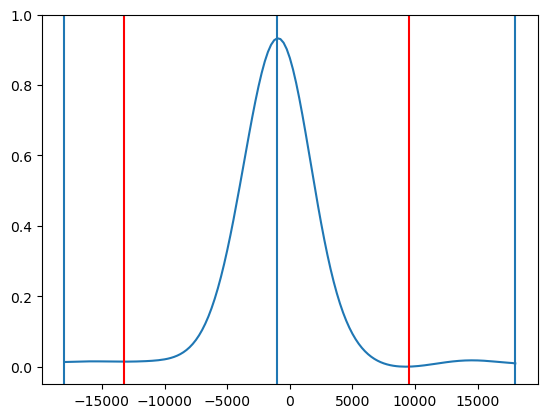

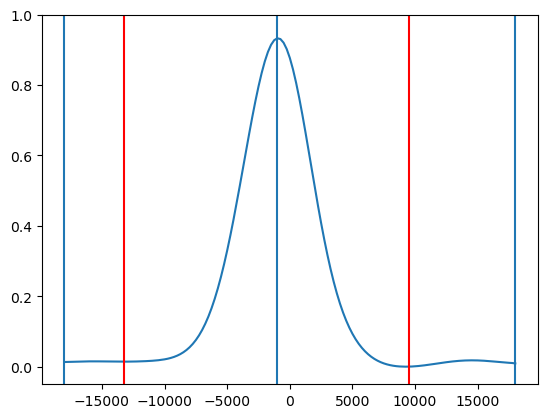

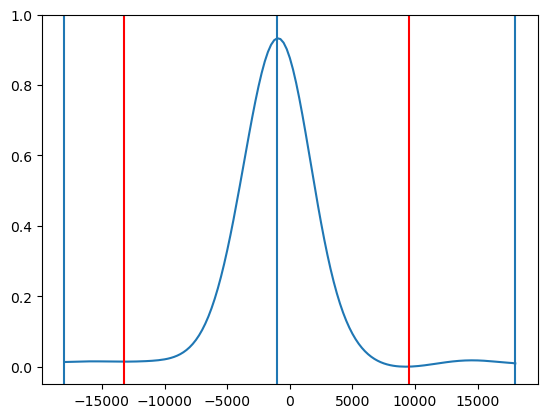

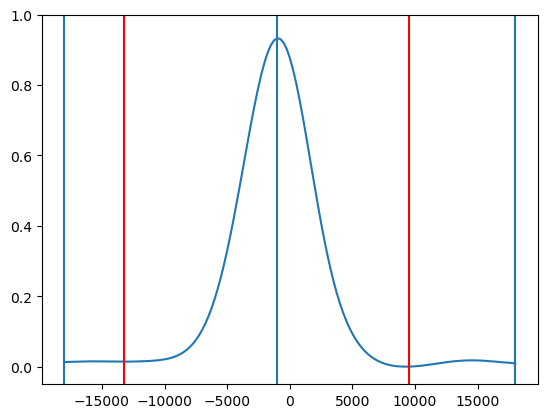

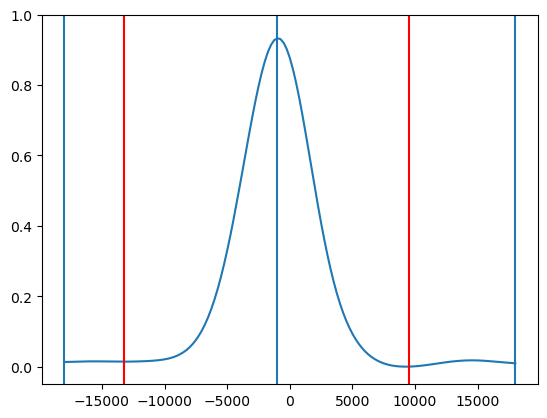

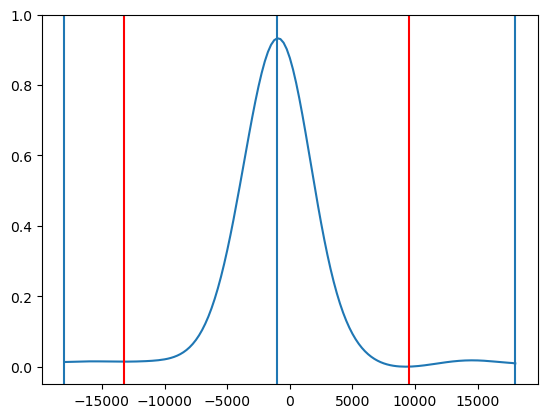

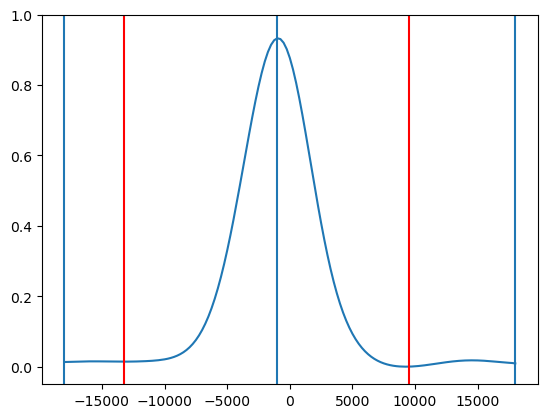

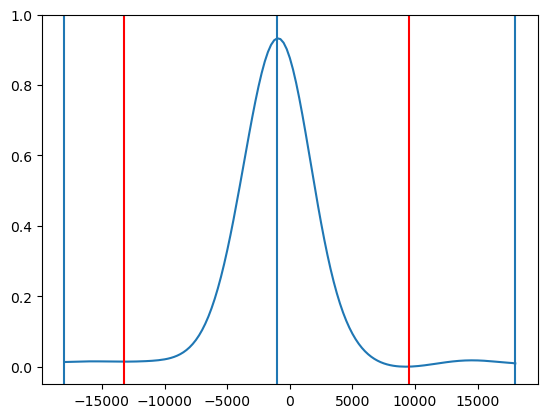

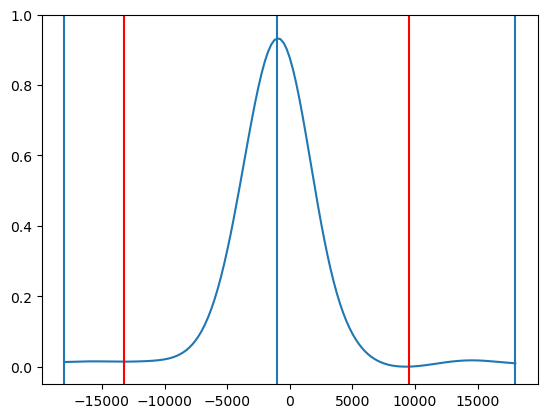

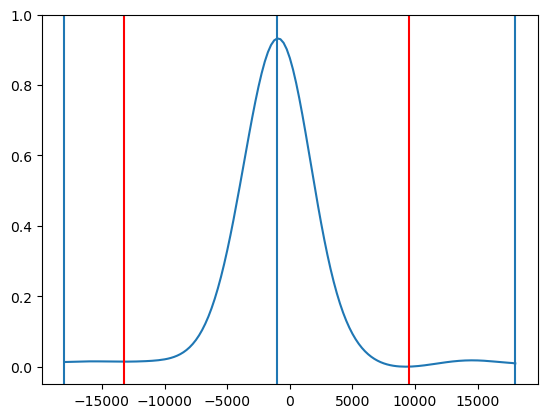

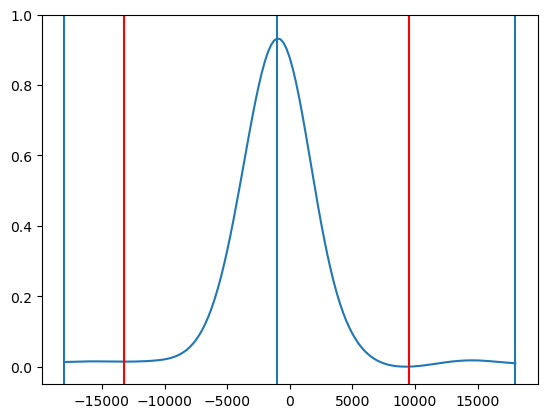

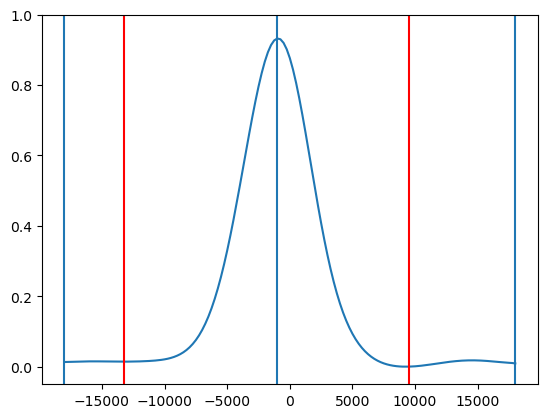

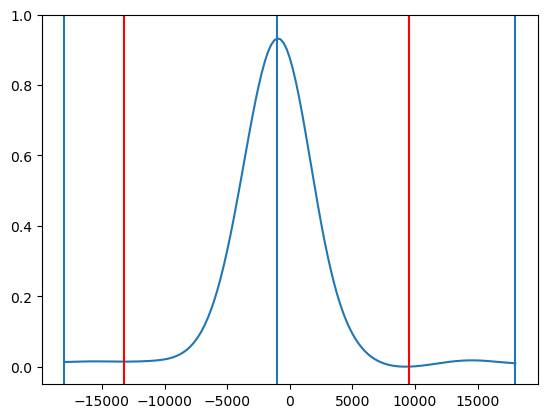

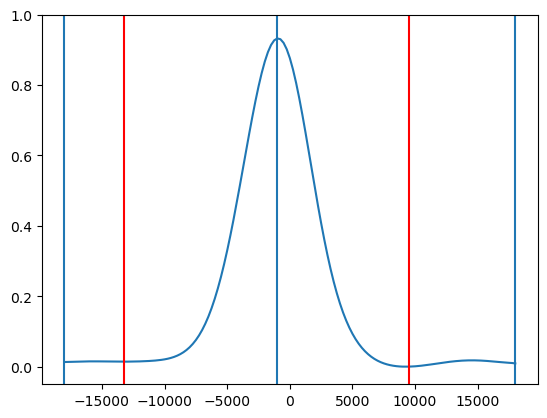

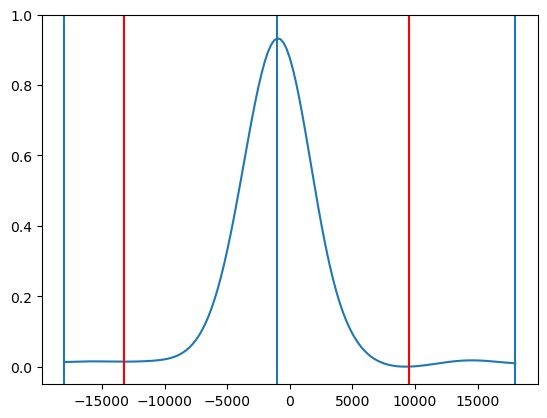

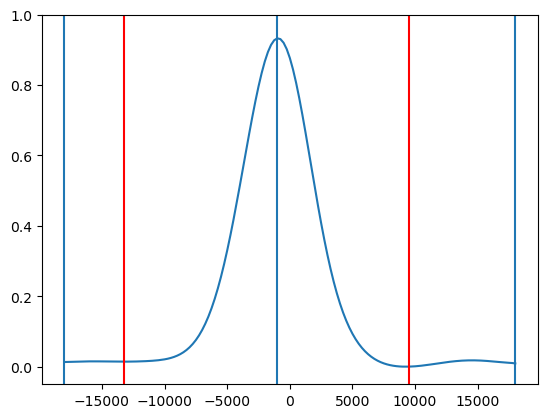

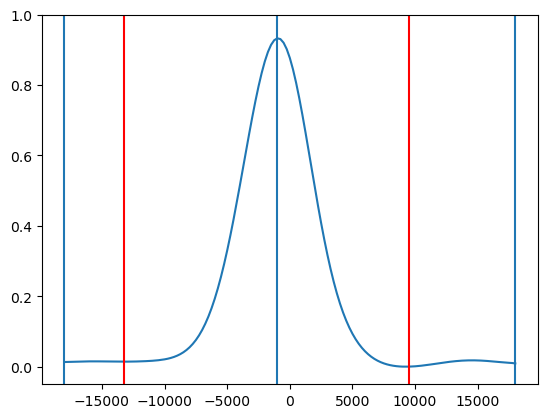

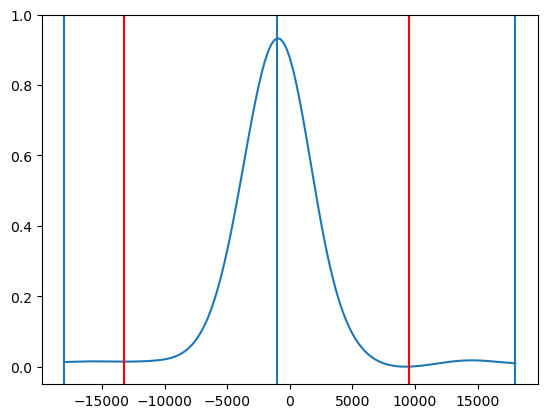

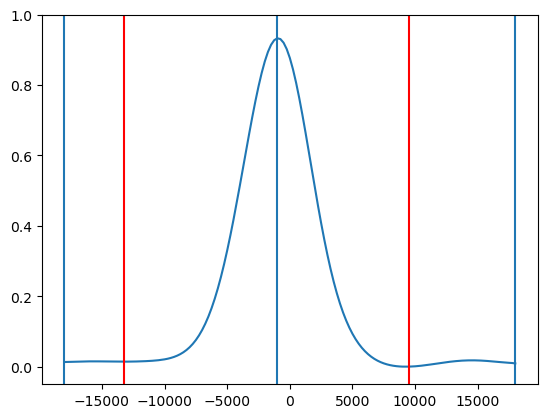

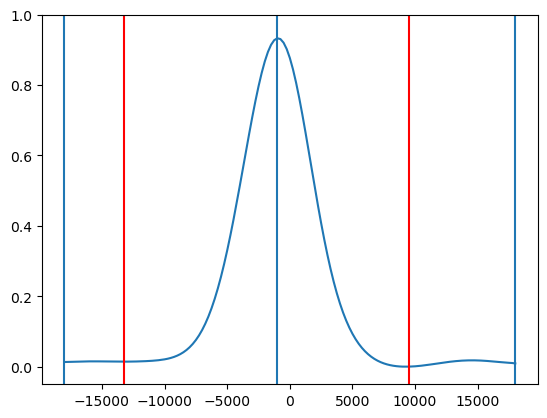

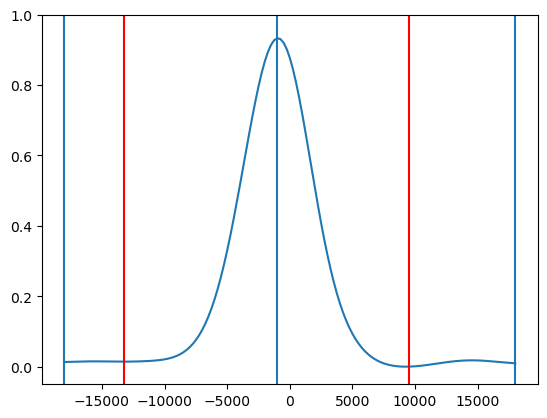

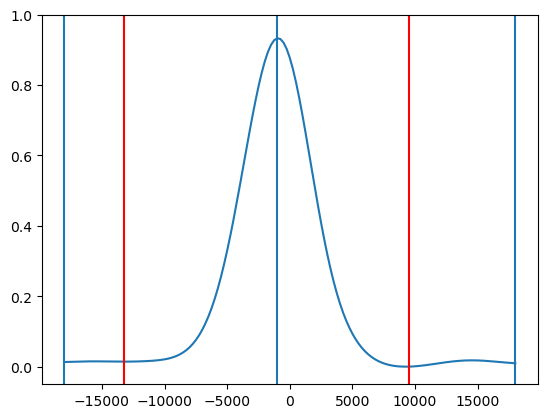

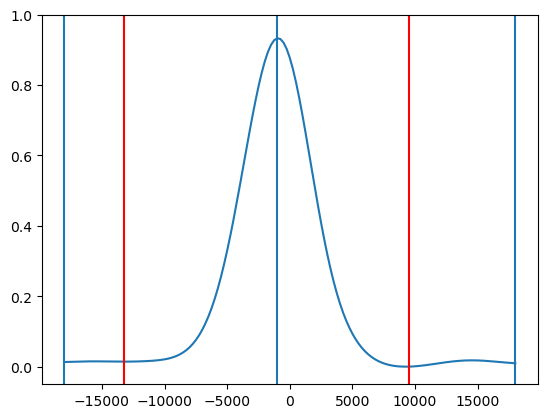

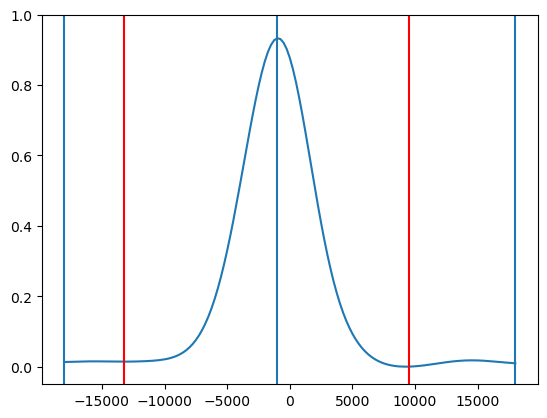

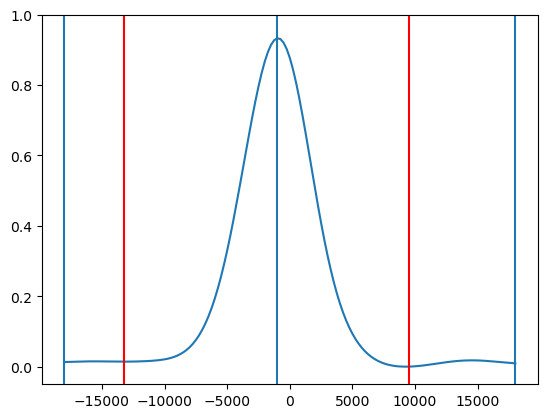

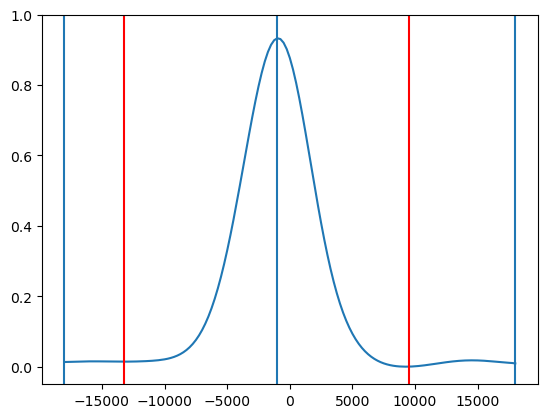

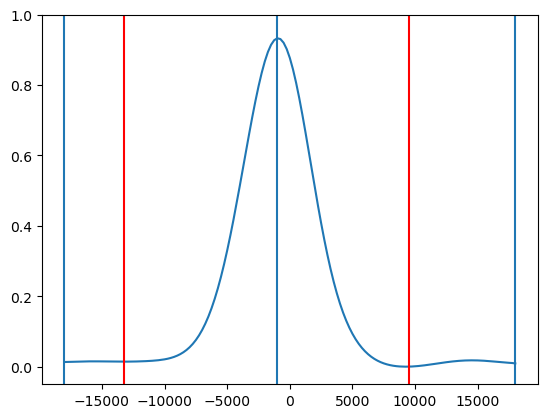

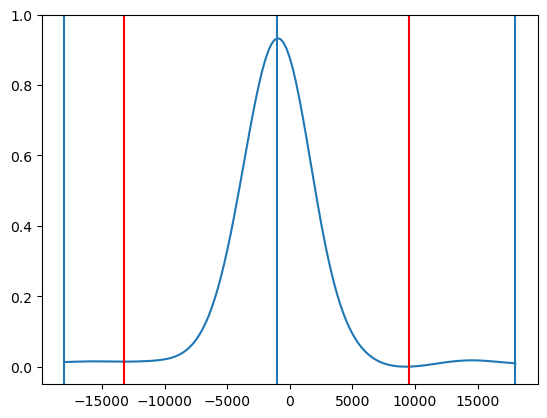

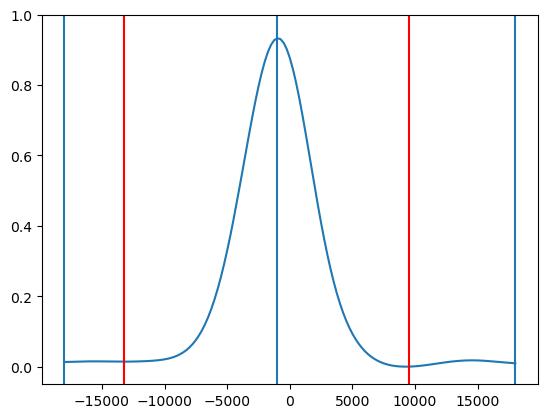

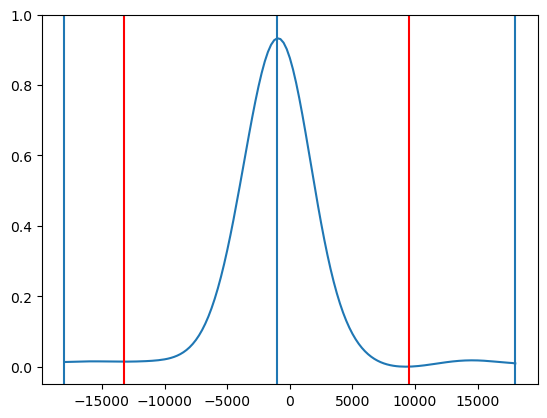

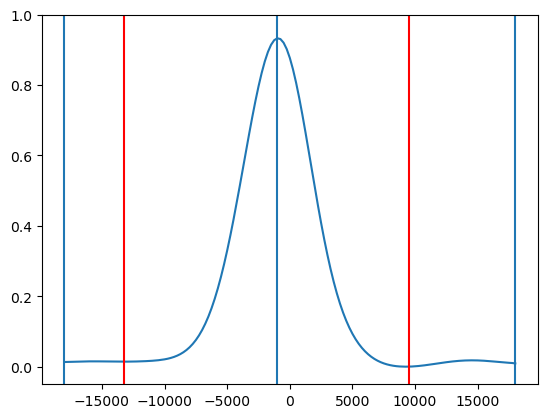

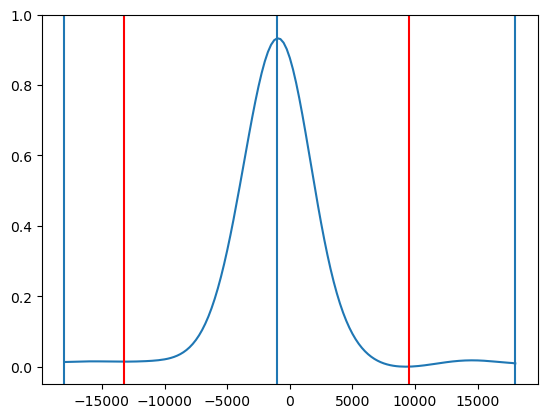

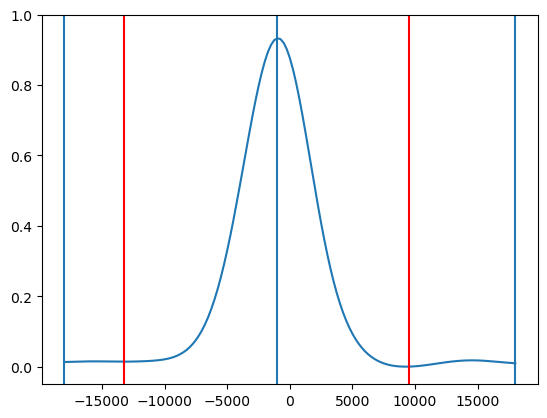

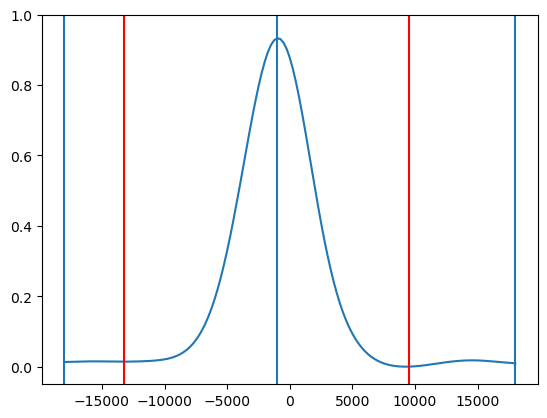

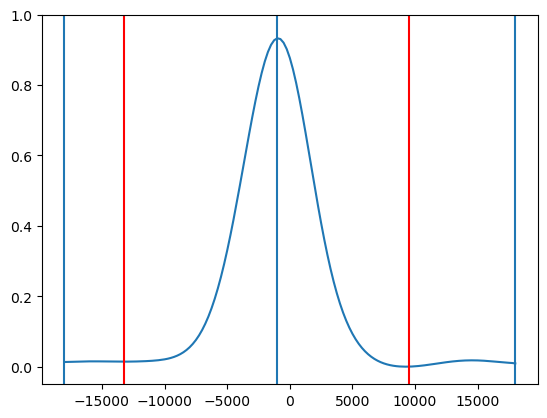

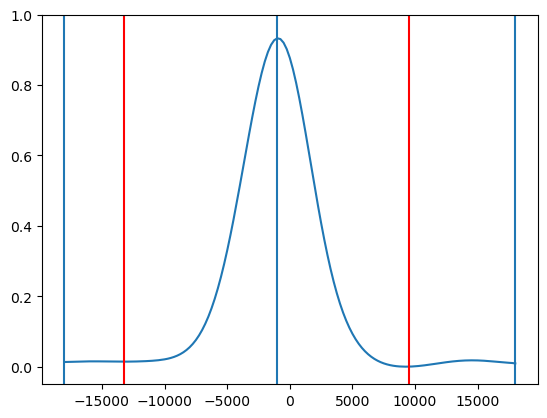

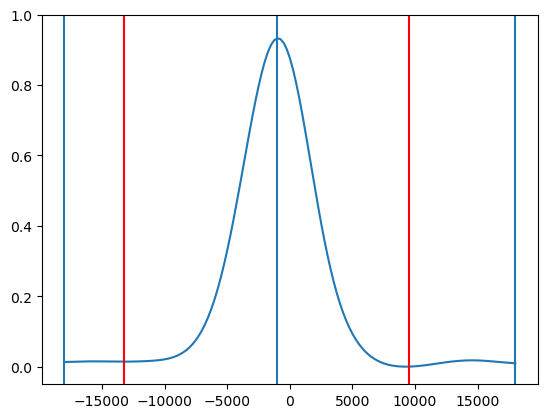

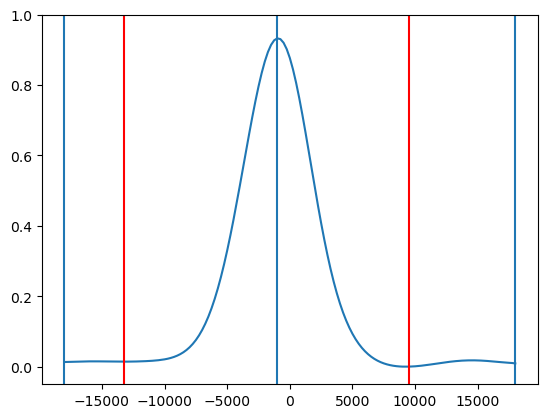

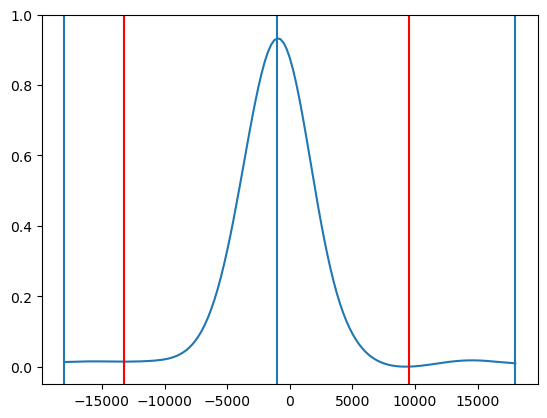

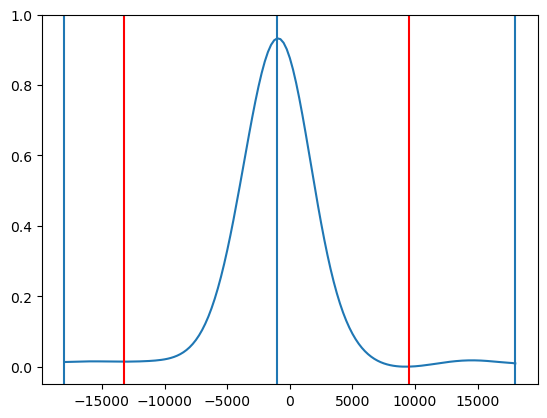

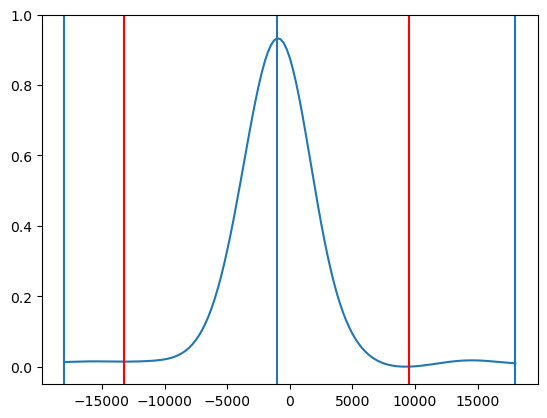

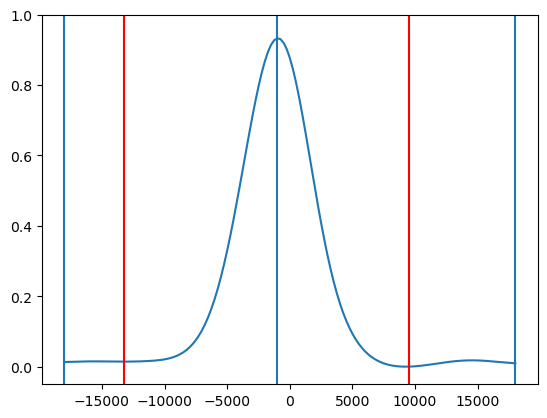

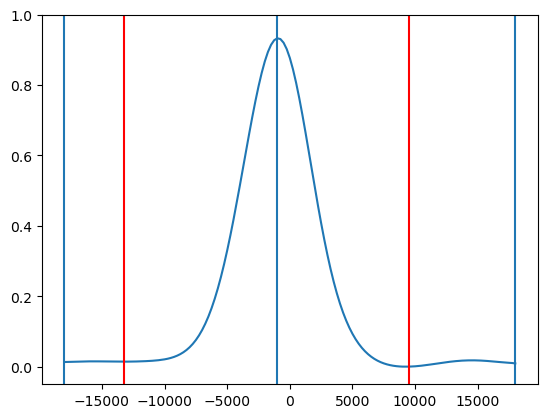

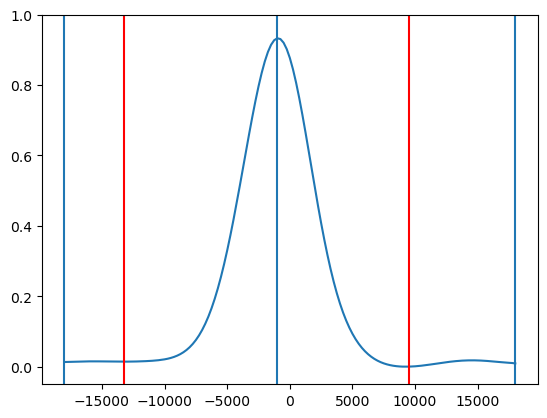

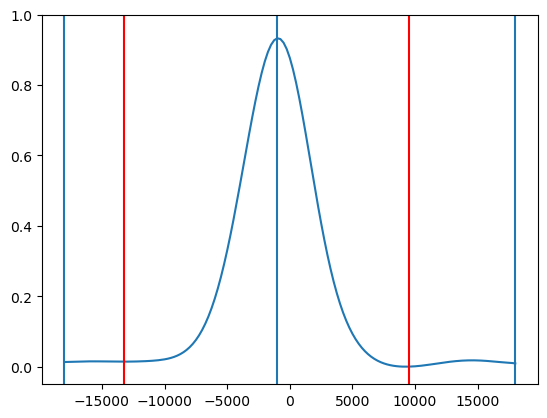

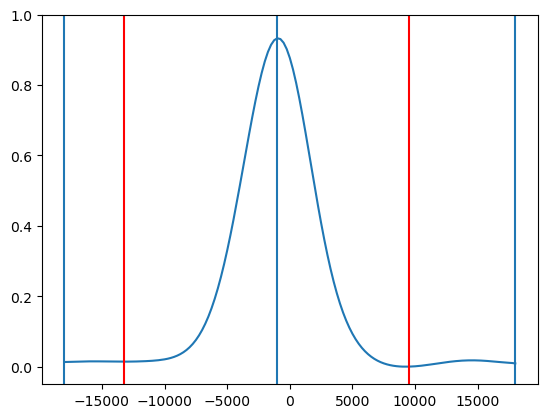

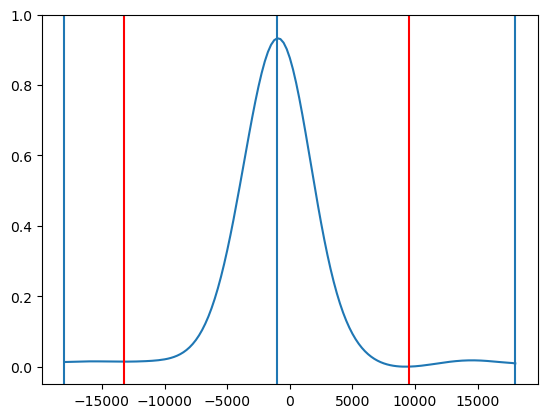

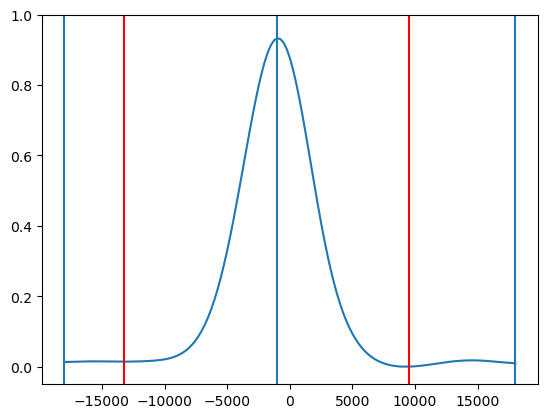

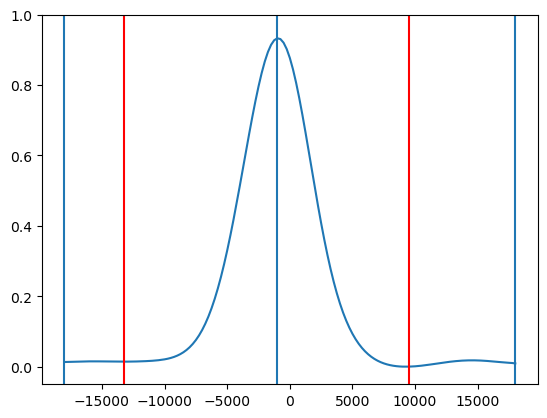

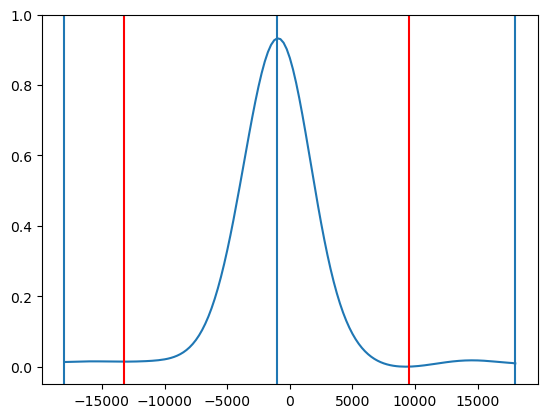

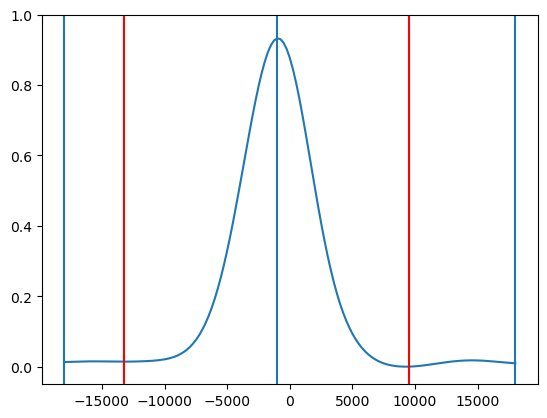

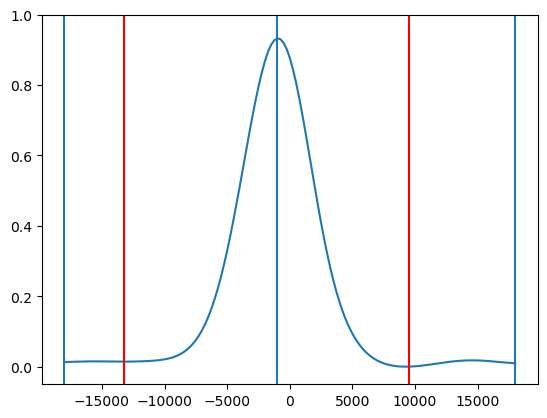

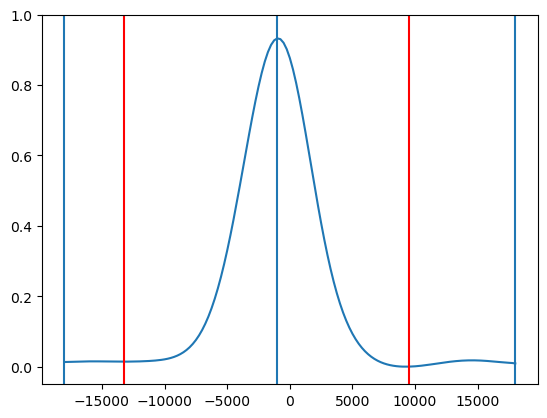

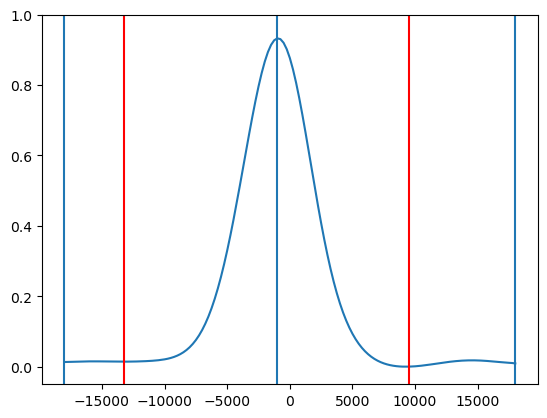

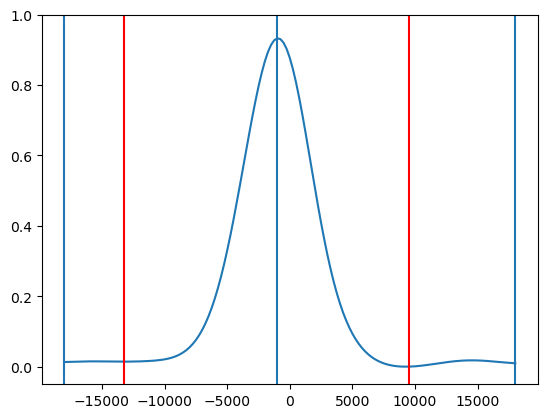

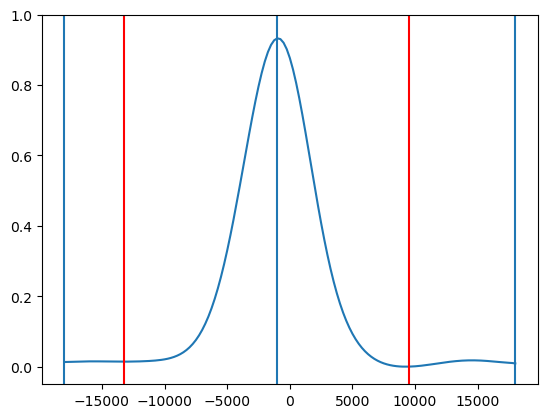

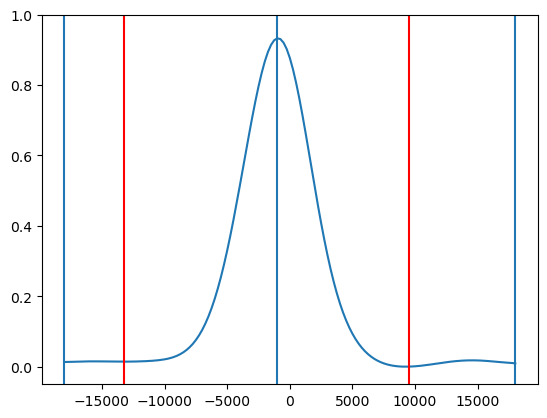

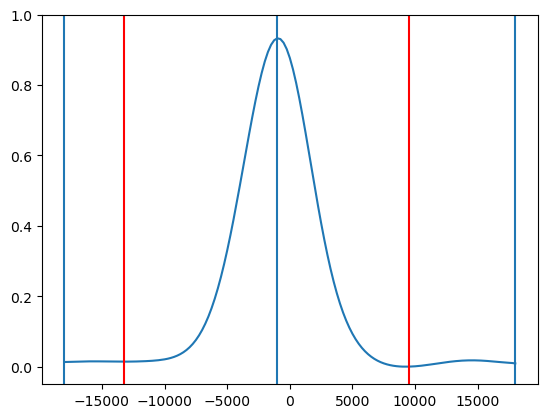

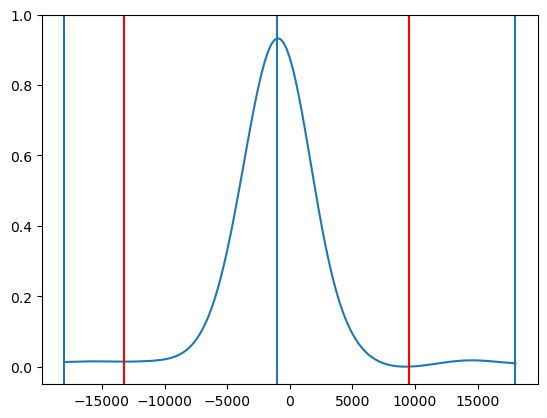

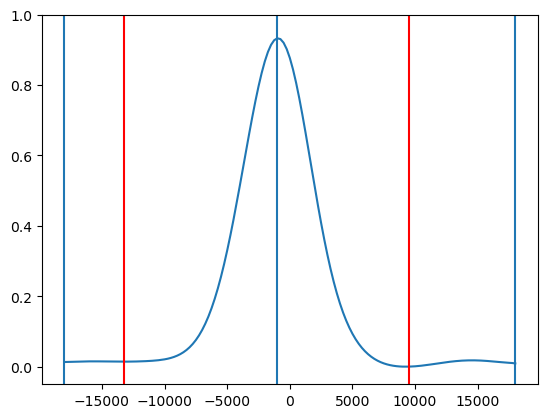

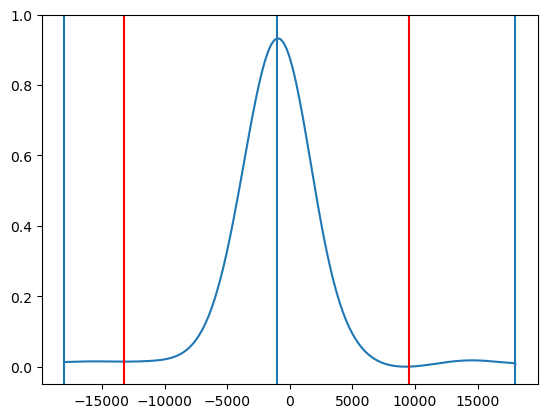

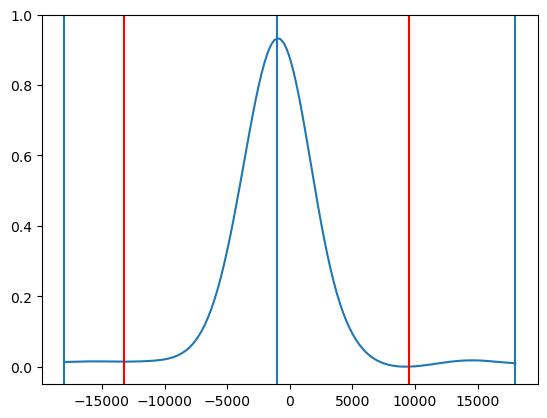

In [4]:
rvs, contrast, fwhm, BIS, raw_xbis, raw_ybis, cutleft, cutright, cutleft_old, cutright_old = compute_ccf_params(ccf_simu_mps[0], ccf_simu_mps[1:], False, change)

for i in range(62):
    plt.plot(ccf_simu_mps[0],ccf_simu_mps[i+1,:])
    
    plt.axvline(rv_simu_mps[i] + rv0, -0.1, 1)
    plt.axvline(ccf_simu_mps[0][cutleft], -0.1, 1)
    plt.axvline(ccf_simu_mps[0][cutright], -0.1, 1)

    plt.axvline(ccf_simu_mps[0][cutleft_old], -0.1, 1, color='r')
    plt.axvline(ccf_simu_mps[0][cutright_old], -0.1, 1, color='r')

    # plt.axvline(np.argmax(ccf_simu_mps[i+1,:]) + rv0, -0.1, 1, color='red')

    plt.ylim(-0.05,1)
    # plt.xlim(rv0-1000, rv0+1000)
    plt.show()

    # print(rv_simu_mps[i] - np.argmax(ccf_simu_mps[i+1,:]))

Text(0, 0.5, 'New')

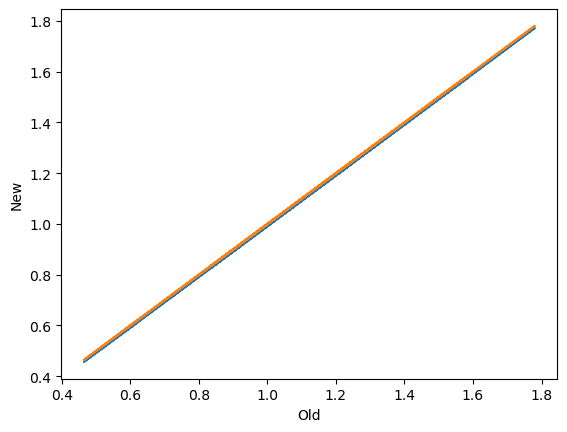

In [5]:
plt.plot(rv_simu_mps, rvs - rv0)
plt.plot(rv_simu_mps, rv_simu_mps)

plt.xlabel('Old')
plt.ylabel('New')

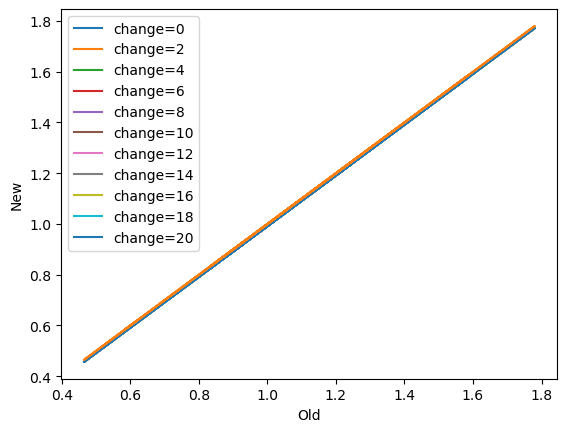

In [6]:
for change in np.linspace(0,20, 11):
    rvs, contrast, fwhm, BIS, raw_xbis, raw_ybis, cutleft, cutright, cutleft_old, cutright_old = compute_ccf_params(ccf_simu_mps[0], ccf_simu_mps[1:], False, int(change))
    plt.plot(rv_simu_mps, rvs - rv0, label='change='+str(int(change)))
plt.plot(rv_simu_mps, rv_simu_mps)

plt.xlabel('Old')
plt.ylabel('New')
plt.legend()
plt.show()




In [14]:
con_list,rv_list,fwhm_list,bis_list,gaussian,ccf_corr,offset =RACCOON_gaussian_corr(1e-3 * ccf_simu_mps[0],( 1- ccf_simu_mps[1:]),mode='all')
#ccf_corr is corrected for the absolute electron count from the instrument
#mode defines if compute the Gaussian fit to the CCF by finding the local or absolute maxima and cutting
#or using the full CCF range to fit the CCF (I think should be the case for the Sun)


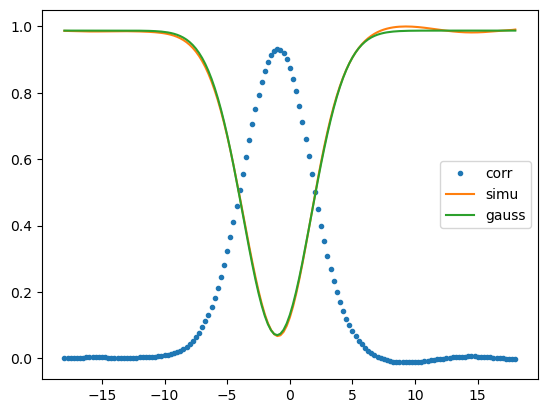

In [8]:
plt.plot(1e-3*ccf_simu_mps[0],ccf_corr[0], '.', label='corr')
plt.plot(1e-3*ccf_simu_mps[0], 1- ccf_simu_mps[1], label='simu')
plt.plot(1e-3*ccf_simu_mps[0],gaussian[0], label='gauss')
# plt.axvline(ifit1)
# plt.axvline(ifit2)

plt.legend()



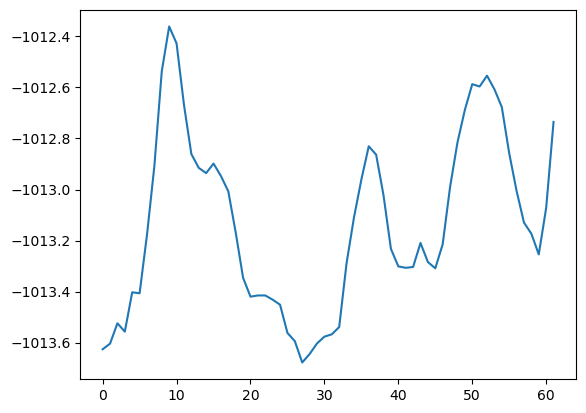

In [9]:
plt.plot(1e3*np.array(rv_list))

In [10]:
fits.getheader('/home/sophie-stucki/Documents/starsim_simulations/harps/sun_spectroscopy_data_ccf_0/2017-07-01/r.HARPN.2017-07-01T10-04-47.444_CCF_A.fits')

SIMPLE  =                    T / file does conform to FITS standard             
BITPIX  =                    8 / number of bits per data pixel                  
NAXIS   =                    0 / number of data axes                            
EXTEND  =                    T / FITS dataset may contain extensions            
COMMENT   FITS (Flexible Image Transport System) format is defined in 'Astronomy
COMMENT   and Astrophysics', volume 376, page 359; bibcode: 2001A&A...376..359H 
DATE    = '2024-06-05T11:14:27' / file creation date (YYYY-MM-DDThh:mm:ss UT)   
TELESCOP= 'TNG     '                                                            
TIMESYS = 'UTC     '           / Explicit time scale specification              
DATE-OBS= '2017-07-01T10:04:47.444' / Date and time of start of obs. in UTC     
INSTRUME= 'HARPN   '           / Instrument generatedName                       
RA      =              6.69152 / Right Ascension (hours as float)               
DEC     =     1.539607722222

In [ ]:
ccf_list = []

base_path = Path("/home/sophie-stucki/Documents/starsim_simulations/harps/")


def open_all_fits_files(root_dir):
    ccf_list = []  # To store opened FITS HDUs or data
    
    for dirpath, dirnames, filenames in os.walk(root_dir):
        for file in filenames:
            if file.lower().endswith('.fits'):
                full_path = os.path.join(dirpath, file)
                try:
                    ccf_header = fits.getheader(full_path)
                    ccf = fits.getdata(full_path, 1)
                    ccf_list.append(ccf[-1] / max(ccf[-1]))

                    CCF_rv =np.arange(
                        ccf_header["TNG RV START"],
                        ccf_header["TNG RV START"] + len(ccf[0]) * ccf_header["TNG RV STEP"],
                        ccf_header["TNG RV STEP"],
                    )

                except Exception as e:
                    print(f"Failed to open {full_path}: {e}")

        
    return CCF_rv, ccf_list

daily_rv = []
days = []
for ccf_dir in sorted(base_path.glob("sun_spectroscopy_data_ccf_*")):
    print(f"\n📂 Processing: {ccf_dir.name}")
    days.append(str(ccf_dir).replace('/home/sophie-stucki/Documents/starsim_simulations/harps/sun_spectroscopy_data_ccf_', ''))
    CCF_rv, ccf = open_all_fits_files(ccf_dir)
    con_list,rv_list,fwhm_list,bis_list,gaussian,ccf_corr,offset =RACCOON_gaussian_corr(CCF_rv,ccf,mode='all')

    daily_rv.append(np.mean(rv_list))

days = np.int32(days)







📂 Processing: sun_spectroscopy_data_ccf_0

📂 Processing: sun_spectroscopy_data_ccf_1

📂 Processing: sun_spectroscopy_data_ccf_10

📂 Processing: sun_spectroscopy_data_ccf_12

📂 Processing: sun_spectroscopy_data_ccf_14

📂 Processing: sun_spectroscopy_data_ccf_15

📂 Processing: sun_spectroscopy_data_ccf_16

📂 Processing: sun_spectroscopy_data_ccf_17

📂 Processing: sun_spectroscopy_data_ccf_18

📂 Processing: sun_spectroscopy_data_ccf_19

📂 Processing: sun_spectroscopy_data_ccf_2

📂 Processing: sun_spectroscopy_data_ccf_20

📂 Processing: sun_spectroscopy_data_ccf_21

📂 Processing: sun_spectroscopy_data_ccf_22

📂 Processing: sun_spectroscopy_data_ccf_23

📂 Processing: sun_spectroscopy_data_ccf_25

📂 Processing: sun_spectroscopy_data_ccf_26

📂 Processing: sun_spectroscopy_data_ccf_27

📂 Processing: sun_spectroscopy_data_ccf_28

📂 Processing: sun_spectroscopy_data_ccf_29

📂 Processing: sun_spectroscopy_data_ccf_3

📂 Processing: sun_spectroscopy_data_ccf_30

📂 Processing: sun_spectroscopy_data

/home/sophie-stucki/anaconda3/envs/starsim/lib/python3.13/site-packages/uncertainties/core.py:1024: UserWarning: Using UFloat objects with std_dev==0 may give unexpected results.
  warn("Using UFloat objects with std_dev==0 may give unexpected results.")



📂 Processing: sun_spectroscopy_data_ccf_55

📂 Processing: sun_spectroscopy_data_ccf_56

📂 Processing: sun_spectroscopy_data_ccf_57

📂 Processing: sun_spectroscopy_data_ccf_58

📂 Processing: sun_spectroscopy_data_ccf_59

📂 Processing: sun_spectroscopy_data_ccf_6

📂 Processing: sun_spectroscopy_data_ccf_60

📂 Processing: sun_spectroscopy_data_ccf_61

📂 Processing: sun_spectroscopy_data_ccf_7

📂 Processing: sun_spectroscopy_data_ccf_8

📂 Processing: sun_spectroscopy_data_ccf_9


In [12]:
for i in range(len(ccf_list)):
    plt.plot(CCF_rv[0], ccf_list[i], '^-', label='HARPS', color="#000000", alpha =0.3)
    plt.plot(CCF_rv[0], gaussian[i], 'o-', label='Gaussian', color="#AE74C9", alpha =0.3)
    plt.legend()
    plt.show()

    plt.plot(CCF_rv[0], ccf_list[i] - gaussian[i], '^-', label='HARPS', color="#000000", alpha =0.3)
    plt.show()


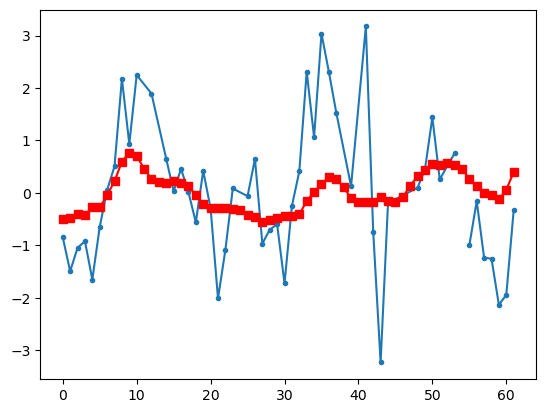

In [15]:
daily_rv[np.nanargmax(daily_rv)] = np.nan
idxs = np.argsort(days)
days= days[idxs]
daily_rv = np.array(daily_rv)[idxs]


plt.plot(days, 1e3 * (np.array(daily_rv) - np.nanmean(daily_rv)), '.-')
plt.plot(range(62), 1e3 * (np.array(rv_list) - np.mean(rv_list)), 'sr-')
df = pd.DataFrame({
        "days": days,
        "rv": daily_rv
    })

df.to_csv('/home/sophie-stucki/Documents/starsim_simulations/harps/rv.csv', index=False)

df2 = pd.DataFrame({
        "days": range(62),
        "rv": 1e3*np.array(rv_list)
    })



In [16]:
df2.to_csv('/home/sophie-stucki/Documents/starsim_simulations/harps/rv_mps_racoon.csv', index=False)
